# 📦 品类分析

**目标**：分析不同品类（Category → Sub-Category）的销售和利润表现，识别核心产品和潜力产品

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置 seaborn 样式
sns.set_style('whitegrid')
sns.set_palette('husl')

print('库加载完成！')

库加载完成！


In [2]:
# 加载数据
df = pd.read_csv('../data/processed/superstore_cleaned.csv')

# 转换日期列
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(f'数据加载成功！共 {len(df)} 条记录')

数据加载成功！共 9994 条记录


## 1. 大品类（Category）分析

In [3]:
# 按品类聚合
category_stats = df.groupby('Category').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Order ID': 'nunique'
}).reset_index()

category_stats.columns = ['Category', 'Total Sales', 'Avg Sales',
                          'Total Profit', 'Avg Profit', 'Total Quantity', 'Orders']
category_stats['Profit Margin'] = (category_stats['Total Profit'] / category_stats['Total Sales'] * 100).round(2)
category_stats['Sales Share'] = (category_stats['Total Sales'] / category_stats['Total Sales'].sum() * 100).round(2)
category_stats['Avg Quantity'] = (category_stats['Total Quantity'] / category_stats['Orders']).round(1)
category_stats = category_stats.sort_values('Total Sales', ascending=False)

print('='*60)
print('📊 品类销售数据')
print('='*60)
print(category_stats.to_string(index=False))

📊 品类销售数据
       Category  Total Sales  Avg Sales  Total Profit  Avg Profit  Total Quantity  Orders  Profit Margin  Sales Share  Avg Quantity
     Technology  836154.0330 452.709276   145454.9481   78.752002            6939    1544          17.40         36.4           4.5
      Furniture  741999.7953 349.834887    18451.2728    8.699327            8028    1764           2.49         32.3           4.6
Office Supplies  719047.0320 119.324101   122490.8008   20.327050           22906    3742          17.04         31.3           6.1


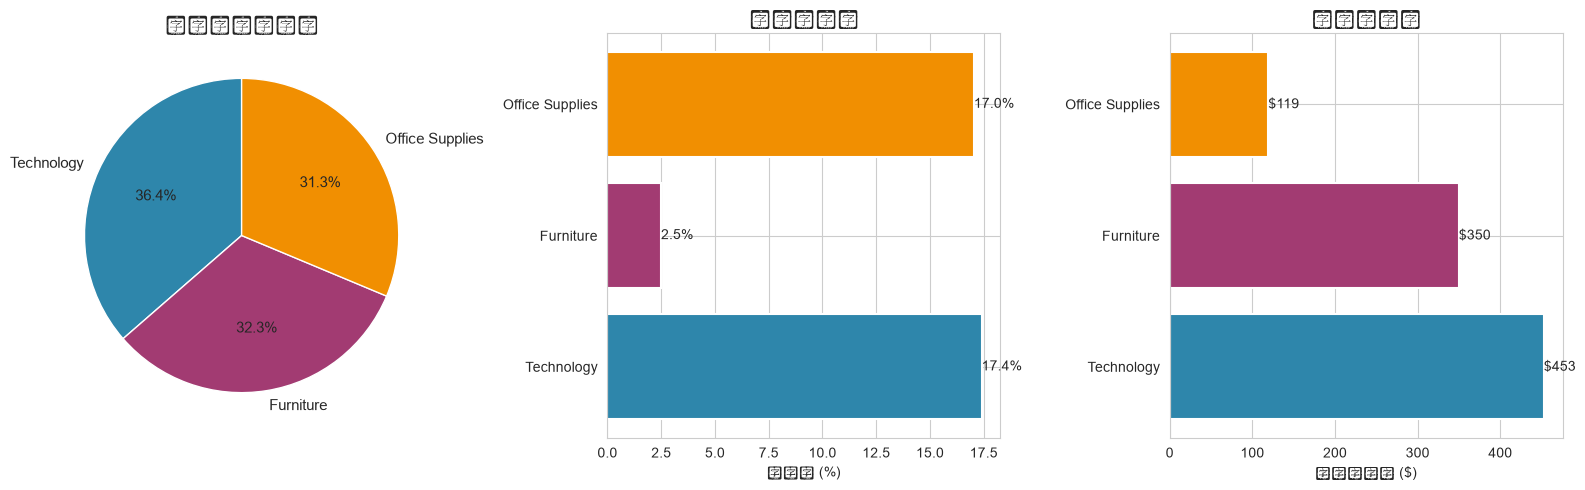

In [4]:
# 品类对比可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 销售额占比
colors_pie = ['#2E86AB', '#A23B72', '#F18F01']
wedges, texts, autotexts = axes[0].pie(
    category_stats['Total Sales'],
    labels=category_stats['Category'],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('品类销售额占比', fontsize=14, fontweight='bold')

# 利润率对比
bars = axes[1].barh(category_stats['Category'], category_stats['Profit Margin'],
                    color=colors_pie, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('利润率 (%)')
axes[1].set_title('品类利润率', fontsize=14, fontweight='bold')
axes[1].bar_label(bars, fmt='%.1f%%', fontsize=10)

# 客单价对比
bars = axes[2].barh(category_stats['Category'], category_stats['Avg Sales'],
                    color=colors_pie, edgecolor='white', linewidth=1.5)
axes[2].set_xlabel('平均销售额 ($)')
axes[2].set_title('品类客单价', fontsize=14, fontweight='bold')
axes[2].bar_label(bars, fmt='$%.0f', fontsize=10)

plt.tight_layout()
plt.show()

## 2. 子品类（Sub-Category）分析

In [5]:
# 按子品类聚合
subcat_stats = df.groupby(['Category', 'Sub-Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Order ID': 'nunique'
}).reset_index()

subcat_stats['Profit Margin'] = (subcat_stats['Profit'] / subcat_stats['Sales'] * 100).round(2)
subcat_stats = subcat_stats.sort_values('Sales', ascending=False)

print('='*60)
print('📊 子品类销售数据')
print('='*60)
print(subcat_stats.to_string(index=False))

📊 子品类销售数据
       Category Sub-Category       Sales      Profit  Quantity  Order ID  Profit Margin
     Technology       Phones 330007.0540  44515.7306      3289       814          13.49
      Furniture       Chairs 328449.1030  26590.1663      2356       576           8.10
Office Supplies      Storage 223843.6080  21278.8264      3158       777           9.51
      Furniture       Tables 206965.5320 -17725.4811      1241       307          -8.56
Office Supplies      Binders 203412.7330  30221.7633      5974      1316          14.86
     Technology     Machines 189238.6310   3384.7569       440       112           1.79
     Technology  Accessories 167380.3180  41936.6357      2976       718          25.05
     Technology      Copiers 149528.0300  55617.8249       234        68          37.20
      Furniture    Bookcases 114879.9963  -3472.5560       868       224          -3.02
Office Supplies   Appliances 107532.1610  18138.0054      1729       451          16.87
      Furniture  Furni

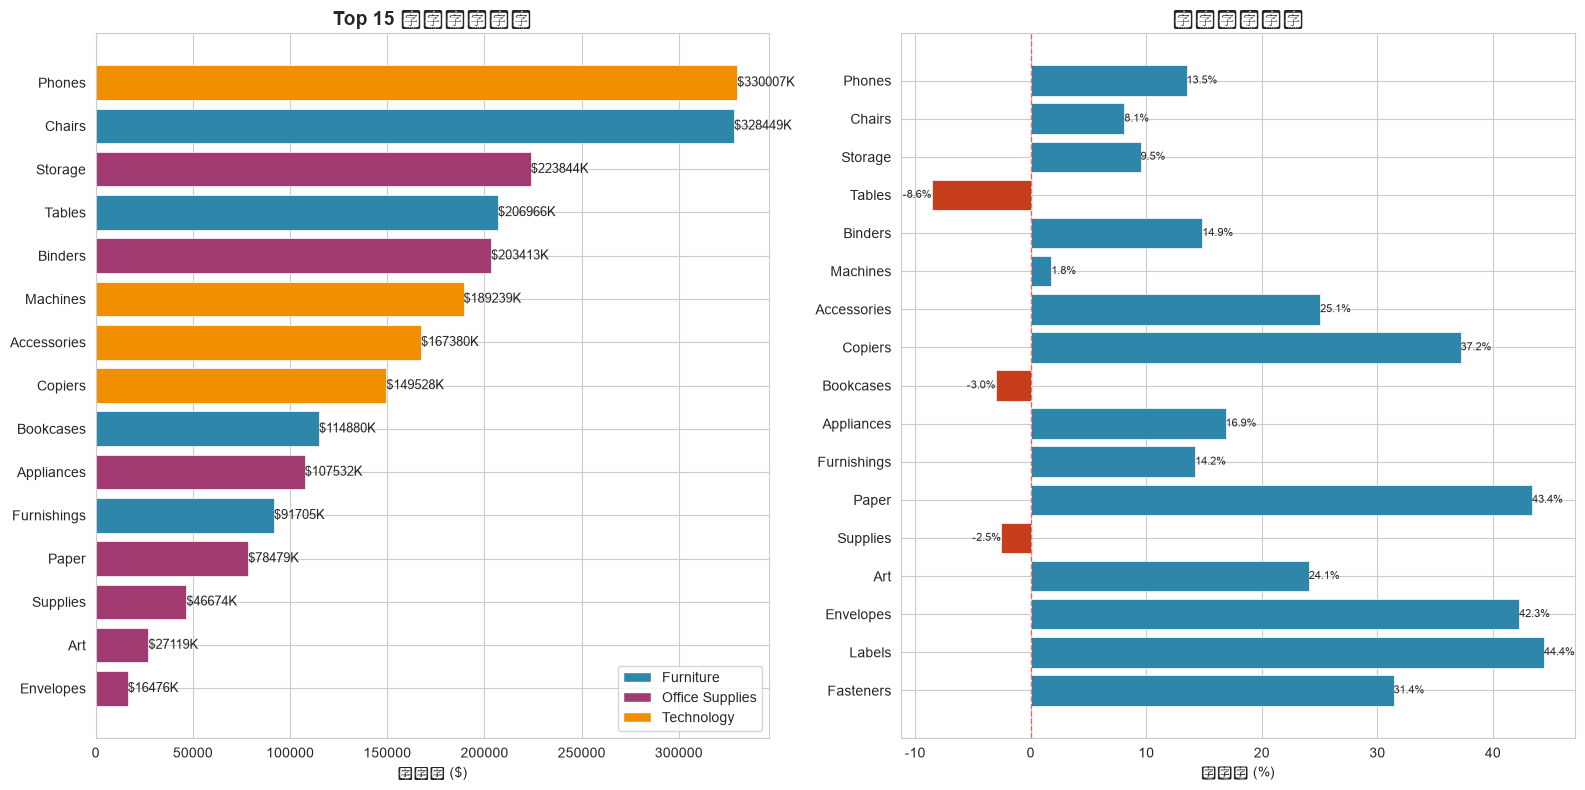

In [6]:
# 子品类可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 按品类分组的子品类销售额
category_colors = {'Furniture': '#2E86AB', 'Office Supplies': '#A23B72', 'Technology': '#F18F01'}

# Top 15 子品类销售额
top15_subcat = subcat_stats.head(15)
colors = [category_colors[cat] for cat in top15_subcat['Category']]
bars = axes[0].barh(top15_subcat['Sub-Category'].iloc[::-1], top15_subcat['Sales'].iloc[::-1],
                    color=colors[::-1], edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('销售额 ($)')
axes[0].set_title('Top 15 子品类销售额', fontsize=14, fontweight='bold')
axes[0].bar_label(bars, fmt='$%.0fK', fontsize=9)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=category_colors[cat], label=cat) for cat in category_colors]
axes[0].legend(handles=legend_elements, loc='lower right')

# 子品类利润率
colors_margin = ['#2E86AB' if x > 0 else '#C73E1D' for x in subcat_stats['Profit Margin'].iloc[::-1]]
bars = axes[1].barh(subcat_stats['Sub-Category'].iloc[::-1], subcat_stats['Profit Margin'].iloc[::-1],
                    color=colors_margin, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('利润率 (%)')
axes[1].set_title('子品类利润率', fontsize=14, fontweight='bold')
axes[1].bar_label(bars, fmt='%.1f%%', fontsize=8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 3. 亏损子品类分析

⚠️ 亏损子品类统计
共 3 个子品类处于亏损状态

       Category Sub-Category       Sales      Profit  Quantity  Order ID  Profit Margin
      Furniture       Tables 206965.5320 -17725.4811      1241       307          -8.56
      Furniture    Bookcases 114879.9963  -3472.5560       868       224          -3.02
Office Supplies     Supplies  46673.5380  -1189.0995       647       187          -2.55


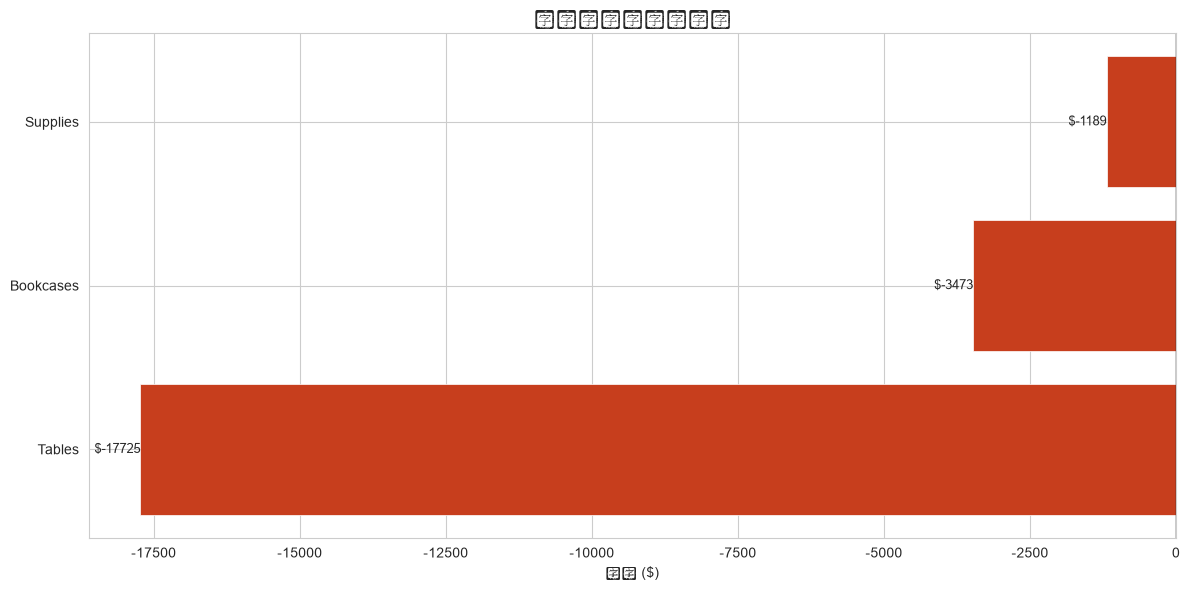

In [7]:
# 找出亏损的子品类
loss_subcat = subcat_stats[subcat_stats['Profit'] < 0].sort_values('Profit')

print('='*60)
print('⚠️ 亏损子品类统计')
print('='*60)
print(f'共 {len(loss_subcat)} 个子品类处于亏损状态')
print()
print(loss_subcat.to_string(index=False))

# 可视化
if len(loss_subcat) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#C73E1D' if x < 0 else '#2E86AB' for x in loss_subcat['Profit']]
    bars = ax.barh(loss_subcat['Sub-Category'], loss_subcat['Profit'],
                   color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('利润 ($)')
    ax.set_title('亏损子品类利润分布', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.bar_label(bars, fmt='$%.0f', fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. 品类×折扣分析

In [8]:
# 品类×折扣分析
df['Discount Range'] = pd.cut(df['Discount'], 
                              bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0],
                              labels=['0-10%', '10-20%', '20-30%', '30-50%', '50%+'])

discount_analysis = df.groupby(['Category', 'Discount Range']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

discount_analysis['Profit Margin'] = (discount_analysis['Profit'] / discount_analysis['Sales'] * 100).round(2)

print('='*60)
print('📊 品类×折扣分析')
print('='*60)
print(discount_analysis.to_string(index=False))

📊 品类×折扣分析
       Category Discount Range       Sales      Profit  Profit Margin
      Furniture          0-10%  46634.2470   7111.0119          15.25
      Furniture         10-20% 244189.5375   7684.9406           3.15
      Furniture         20-30%  99470.3500 -10695.3169         -10.75
      Furniture         30-50%  86576.3088 -33942.8446         -39.21
      Furniture           50%+   9104.0820  -9839.5946        -108.08
Office Supplies          0-10%   4324.1490   1086.0808          25.12
Office Supplies         10-20% 233049.7360  38038.7512          16.32
Office Supplies           50%+  39523.1470 -47140.1376        -119.27
     Technology          0-10%   3410.9550    832.0843          24.39
     Technology         10-20% 314913.6160  46032.6057          14.62
     Technology         20-30%   3756.3050    326.0395           8.68
     Technology         30-50% 108738.4480 -14504.8827         -13.34
     Technology           50%+  15601.5090 -19579.3191        -125.50


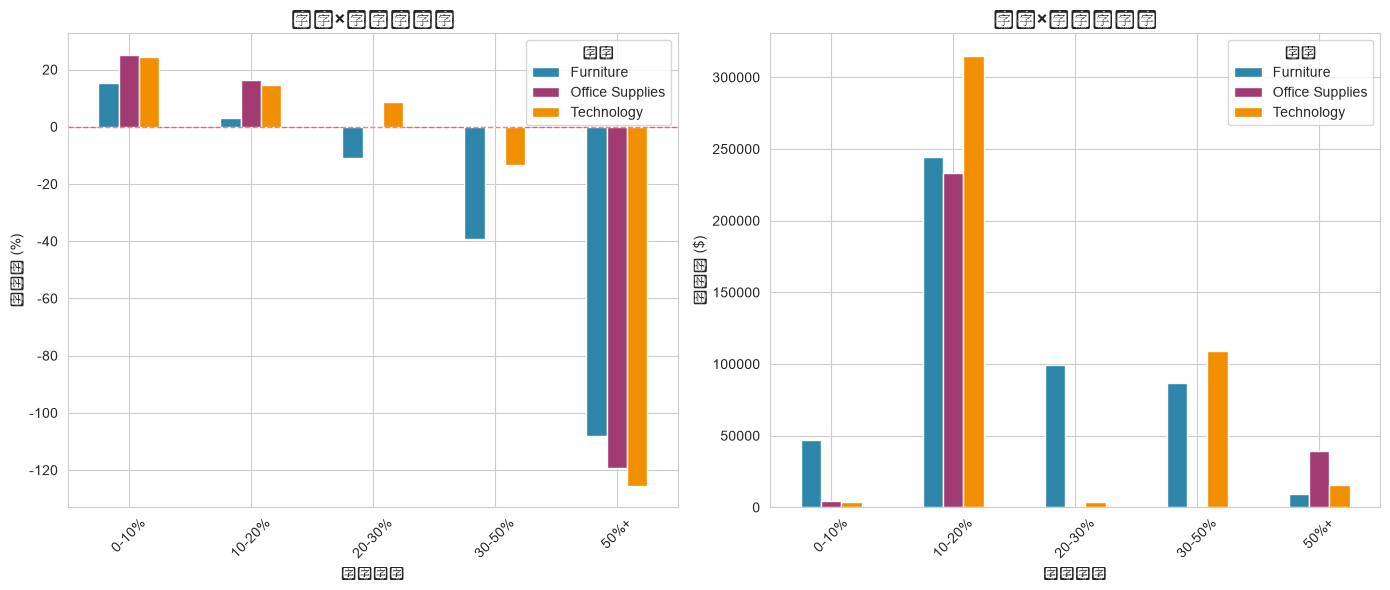

In [9]:
# 折扣与利润率关系可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 按品类的折扣利润率
pivot_margin = discount_analysis.pivot(index='Discount Range', columns='Category', values='Profit Margin')
pivot_margin.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72', '#F18F01'])
axes[0].set_xlabel('折扣范围')
axes[0].set_ylabel('利润率 (%)')
axes[0].set_title('品类×折扣利润率', fontsize=14, fontweight='bold')
axes[0].legend(title='品类')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# 按品类的折扣销售额
pivot_sales = discount_analysis.pivot(index='Discount Range', columns='Category', values='Sales')
pivot_sales.plot(kind='bar', ax=axes[1], color=['#2E86AB', '#A23B72', '#F18F01'])
axes[1].set_xlabel('折扣范围')
axes[1].set_ylabel('销售额 ($)')
axes[1].set_title('品类×折扣销售额', fontsize=14, fontweight='bold')
axes[1].legend(title='品类')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. 产品销售排行

In [10]:
# Top 20 产品销售额
product_sales = df.groupby(['Product Name', 'Category', 'Sub-Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()
product_sales['Profit Margin'] = (product_sales['Profit'] / product_sales['Sales'] * 100).round(2)
product_sales = product_sales.sort_values('Sales', ascending=False)

top20_products = product_sales.head(20)

print('='*60)
print('📊 Top 20 产品销售额')
print('='*60)
print(top20_products[['Product Name', 'Category', 'Sales', 'Profit', 'Profit Margin']].to_string(index=False))

📊 Top 20 产品销售额
                                                               Product Name        Category      Sales        Profit  Profit Margin
                                      Canon imageCLASS 2200 Advanced Copier      Technology 61599.8240  2.519993e+04          40.91
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind Office Supplies 27453.3840  7.753039e+03          28.24
                      Cisco TelePresence System EX90 Videoconferencing Unit      Technology 22638.4800 -1.811078e+03          -8.00
                               HON 5400 Series Task Chairs for Big and Tall       Furniture 21870.5760  5.684342e-14           0.00
                                 GBC DocuBind TL300 Electric Binding System Office Supplies 19823.4790  2.233505e+03          11.27
                           GBC Ibimaster 500 Manual ProClick Binding System Office Supplies 19024.5000  7.609800e+02           4.00
                                       Hewlett Packard LaserJ

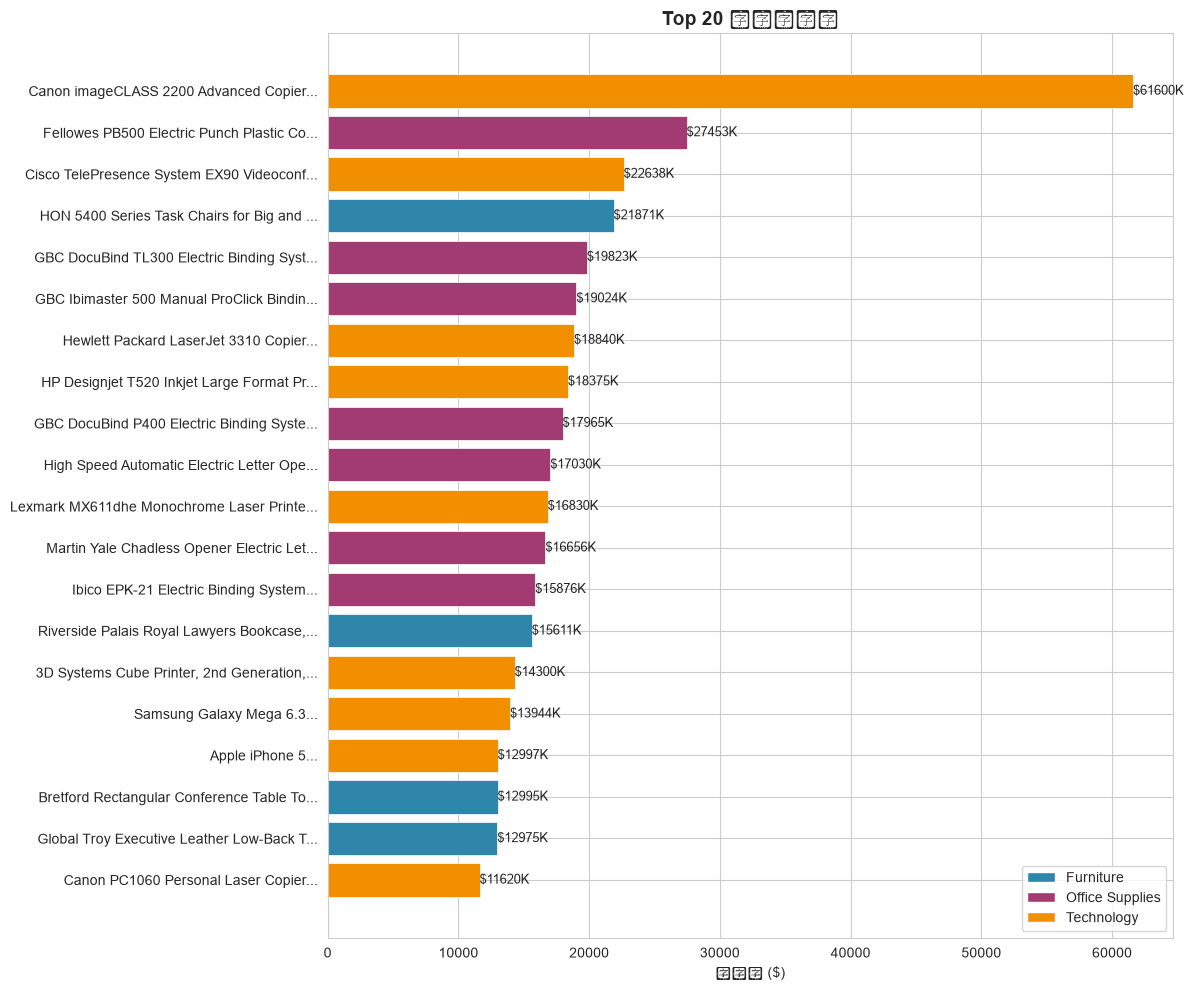

In [11]:
# Top 20 产品可视化
fig, ax = plt.subplots(figsize=(12, 10))

category_colors = {'Furniture': '#2E86AB', 'Office Supplies': '#A23B72', 'Technology': '#F18F01'}
colors = [category_colors[cat] for cat in top20_products['Category']]

# 截断产品名称
top20_products['Short Name'] = top20_products['Product Name'].str[:40] + '...'

bars = ax.barh(top20_products['Short Name'].iloc[::-1], top20_products['Sales'].iloc[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('销售额 ($)')
ax.set_title('Top 20 产品销售额', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='$%.0fK', fontsize=9)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=category_colors[cat], label=cat) for cat in category_colors]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## 6. 关键发现

In [12]:
# 计算关键指标
best_category = category_stats.iloc[0]
best_subcat = subcat_stats.iloc[0]
best_product = product_sales.iloc[0]

print('='*60)
print('💡 关键发现')
print('='*60)
print(f'\n🏆 最佳品类：{best_category["Category"]}')
print(f'   - 销售额：${best_category["Total Sales"]:,.2f}')
print(f'   - 占比：{best_category["Sales Share"]:.1f}%')
print(f'   - 利润率：{best_category["Profit Margin"]:.1f}%')

print(f'\n📦 最佳子品类：{best_subcat["Sub-Category"]} ({best_subcat["Category"]})')
print(f'   - 销售额：${best_subcat["Sales"]:,.2f}')
print(f'   - 利润率：{best_subcat["Profit Margin"]:.1f}%')

print(f'\n🥇 最佳产品：{best_product["Product Name"][:50]}...')
print(f'   - 销售额：${best_product["Sales"]:,.2f}')
print(f'   - 利润率：{best_product["Profit Margin"]:.1f}%')

print(f'\n⚠️  亏损子品类数量：{len(loss_subcat)}')
if len(loss_subcat) > 0:
    print(f'   - 主要亏损子品类：{", ".join(loss_subcat["Sub-Category"].head(3).tolist())}')

💡 关键发现

🏆 最佳品类：Technology
   - 销售额：$836,154.03
   - 占比：36.4%
   - 利润率：17.4%

📦 最佳子品类：Phones (Technology)
   - 销售额：$330,007.05
   - 利润率：13.5%

🥇 最佳产品：Canon imageCLASS 2200 Advanced Copier...
   - 销售额：$61,599.82
   - 利润率：40.9%

⚠️  亏损子品类数量：3
   - 主要亏损子品类：Tables, Bookcases, Supplies
